# 01. Разведочный анализ данных (EDA)
Датасет: Employee Attrition Prediction Dataset (10 000 записей)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Настройки визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Загрузка данных
df = pd.read_csv('../data/raw/employee_attrition_dataset_10000.csv')
print(f'Размер датасета: {df.shape}')

Размер датасета: (10000, 26)


In [3]:
# Первые 5 строк
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [4]:
# Информация о столбцах и типах данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    10000 non-null  int64
 1   Age                            10000 non-null  int64
 2   Gender                         10000 non-null  str  
 3   Marital_Status                 10000 non-null  str  
 4   Department                     10000 non-null  str  
 5   Job_Role                       10000 non-null  str  
 6   Job_Level                      10000 non-null  int64
 7   Monthly_Income                 10000 non-null  int64
 8   Hourly_Rate                    10000 non-null  int64
 9   Years_at_Company               10000 non-null  int64
 10  Years_in_Current_Role          10000 non-null  int64
 11  Years_Since_Last_Promotion     10000 non-null  int64
 12  Work_Life_Balance              10000 non-null  int64
 13  Job_Satisfaction            

## Проверка пропусков и дубликатов

In [5]:
print('Пропуски в данных:')
print(df.isnull().sum())
print(f'\nВсего пропущенных значений: {df.isnull().sum().sum()}')

Пропуски в данных:
Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64

Всего пропущенных значений: 0


In [6]:
print(f'Количество полных дубликатов: {df.duplicated().sum()}')

Количество полных дубликатов: 0


## Целевая переменная (Attrition)

In [7]:
# Распределение увольнений
attrition_counts = df['Attrition'].value_counts()
attrition_counts

Attrition
No     8003
Yes    1997
Name: count, dtype: int64

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_28784\4184149828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df, palette=colors)


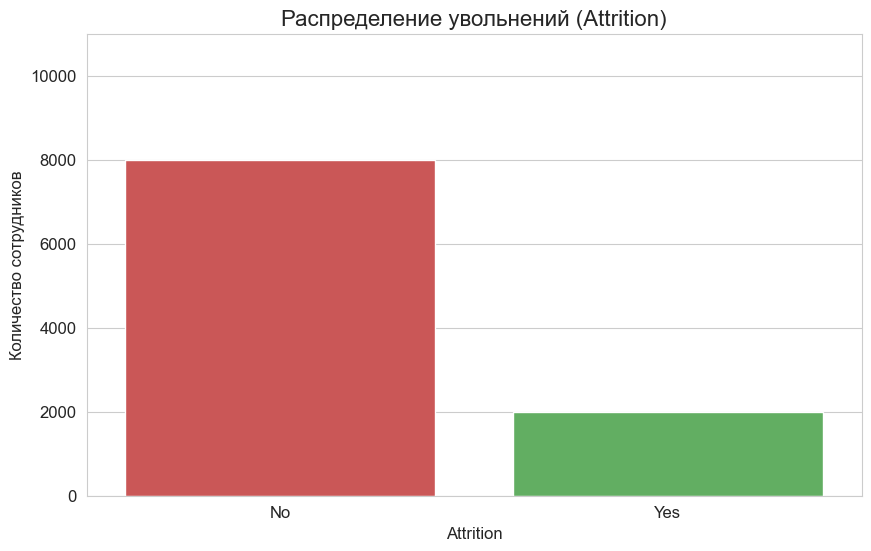

In [13]:
# Сравнение количества
colors = {'No': '#dd4444', 'Yes': '#55bb55'}
ax = sns.countplot(x='Attrition', data=df, palette=colors)
plt.title('Распределение увольнений (Attrition)', fontsize=16)
plt.ylabel('Количество сотрудников')
plt.ylim(0, total * 1.1)  # немного растянем верх для места подписям
plt.show()

In [14]:
# Процентное соотношение
total = len(df)
for label, count in attrition_counts.items():
    print(f'{label}: {count} ({count/total:.2%})')

No: 8003 (80.03%)
Yes: 1997 (19.97%)


## Анализ числовых признаков

In [16]:
# Список числовых колонок
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Убираем Employee_ID, если есть
numeric_cols = [col for col in numeric_cols if col != 'Employee_ID']
print('Числовые признаки:', numeric_cols)
df[numeric_cols].describe().round(2)

Числовые признаки: ['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']


,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,39.56,2.99,11436.72,57.03,14.94,7.45,4.47,2.50,3.04,2.51,49.59,4.98,44.47,9.41,2.49,2.49,2.51,25.27,2.52
std,11.45,1.41,4926.53,24.70,8.43,4.04,2.89,1.11,1.41,1.12,28.80,2.58,8.61,5.76,1.12,1.12,1.12,14.22,1.11
min,20.00,1.00,3000.00,15.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,1.00,30.00,0.00,1.00,1.00,1.00,1.00,1.00
25%,30.00,2.00,7182.50,36.00,8.00,4.00,2.00,2.00,2.00,2.00,25.00,3.00,37.00,4.00,1.00,1.00,2.00,13.00,2.00
50%,40.00,3.00,11401.50,57.00,15.00,7.00,4.00,2.00,3.00,3.00,49.00,5.00,45.00,9.00,2.00,2.00,3.00,25.00,2.00
75%,49.00,4.00,15679.50,78.00,22.00,11.00,7.00,3.00,4.00,4.00,75.00,7.00,52.00,14.00,4.00,3.00,3.00,37.00,4.00
max,59.00,5.00,19999.00,99.00,29.00,14.00,9.00,4.00,5.00,4.00,99.00,9.00,59.00,19.00,4.00,4.00,4.00,49.00,4.00


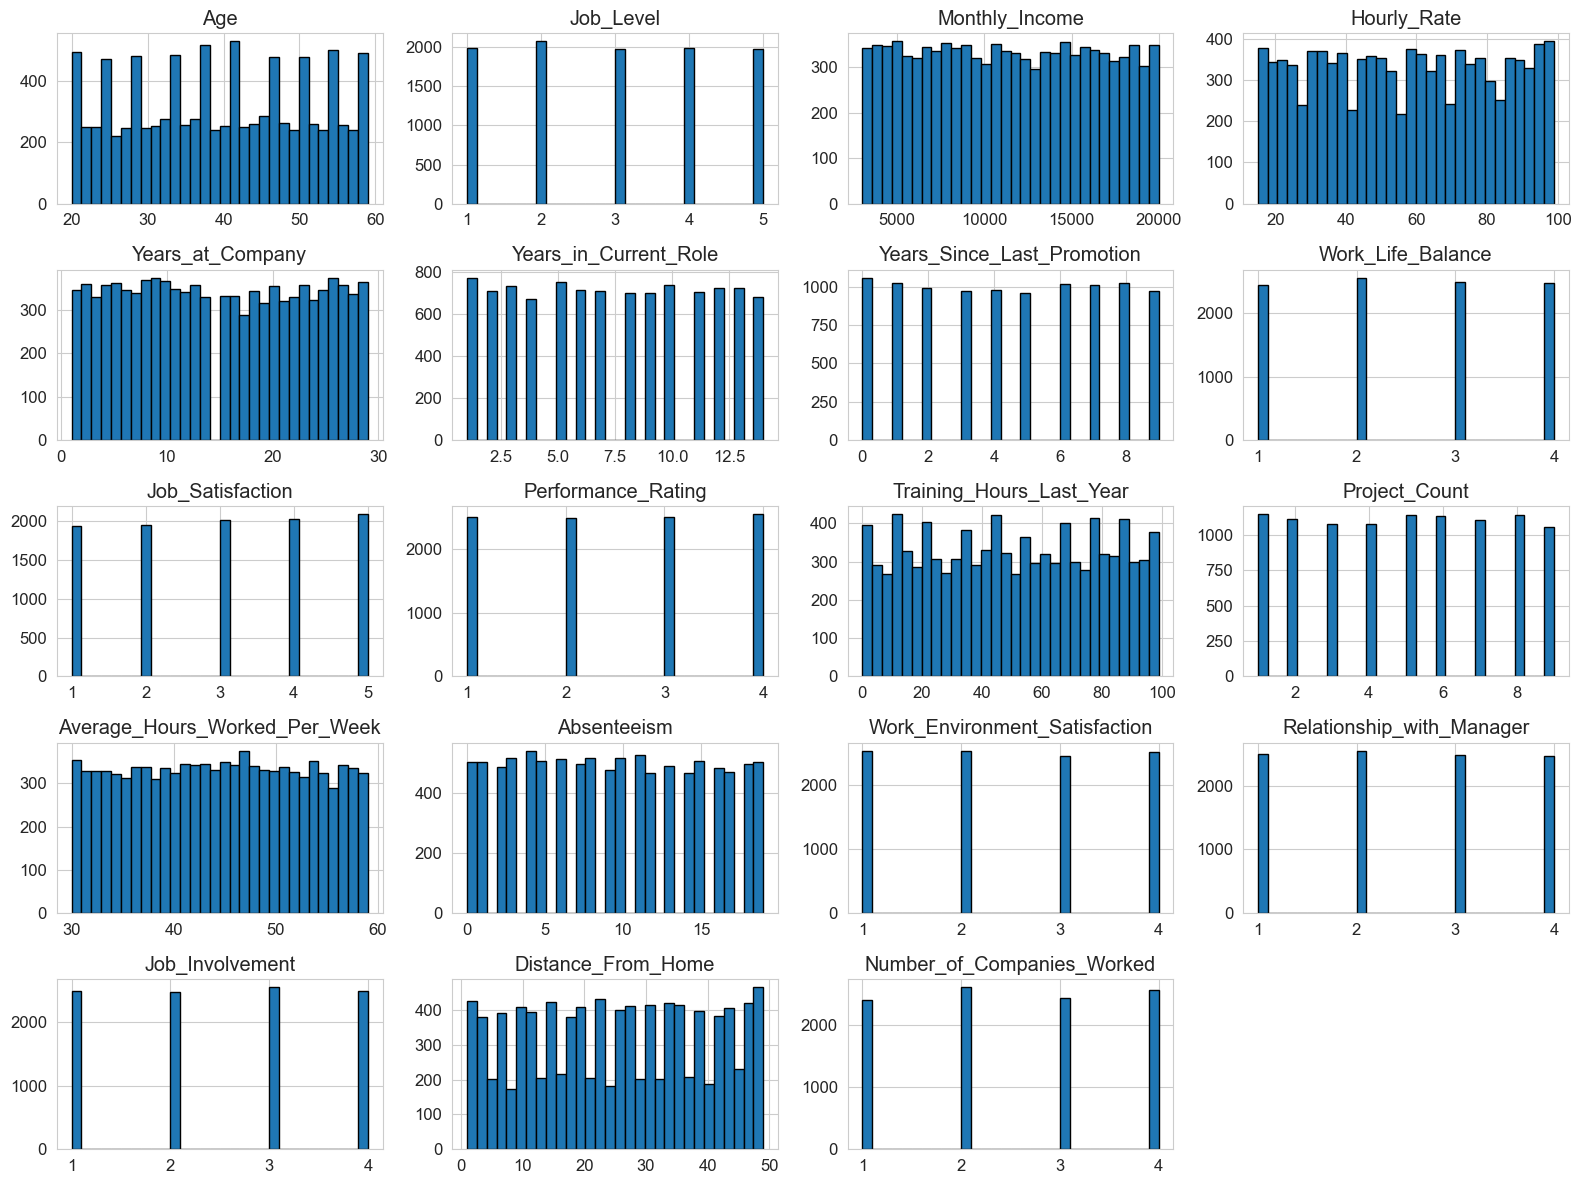

In [17]:
# Гистограммы распределения числовых признаков
df[numeric_cols].hist(bins=30, figsize=(16, 12), edgecolor='black')
plt.tight_layout()
plt.show()

## Числовые признаки в разрезе увольнения
Смотрим, как отличаются распределения для уволившихся и оставшихся.

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_28784\1253122516.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette=colors, ax=axes[i])
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_28784\1253122516.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette=colors, ax=axes[i])
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_28784\1253122516.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette=colors, ax=axes[i])
C:\User

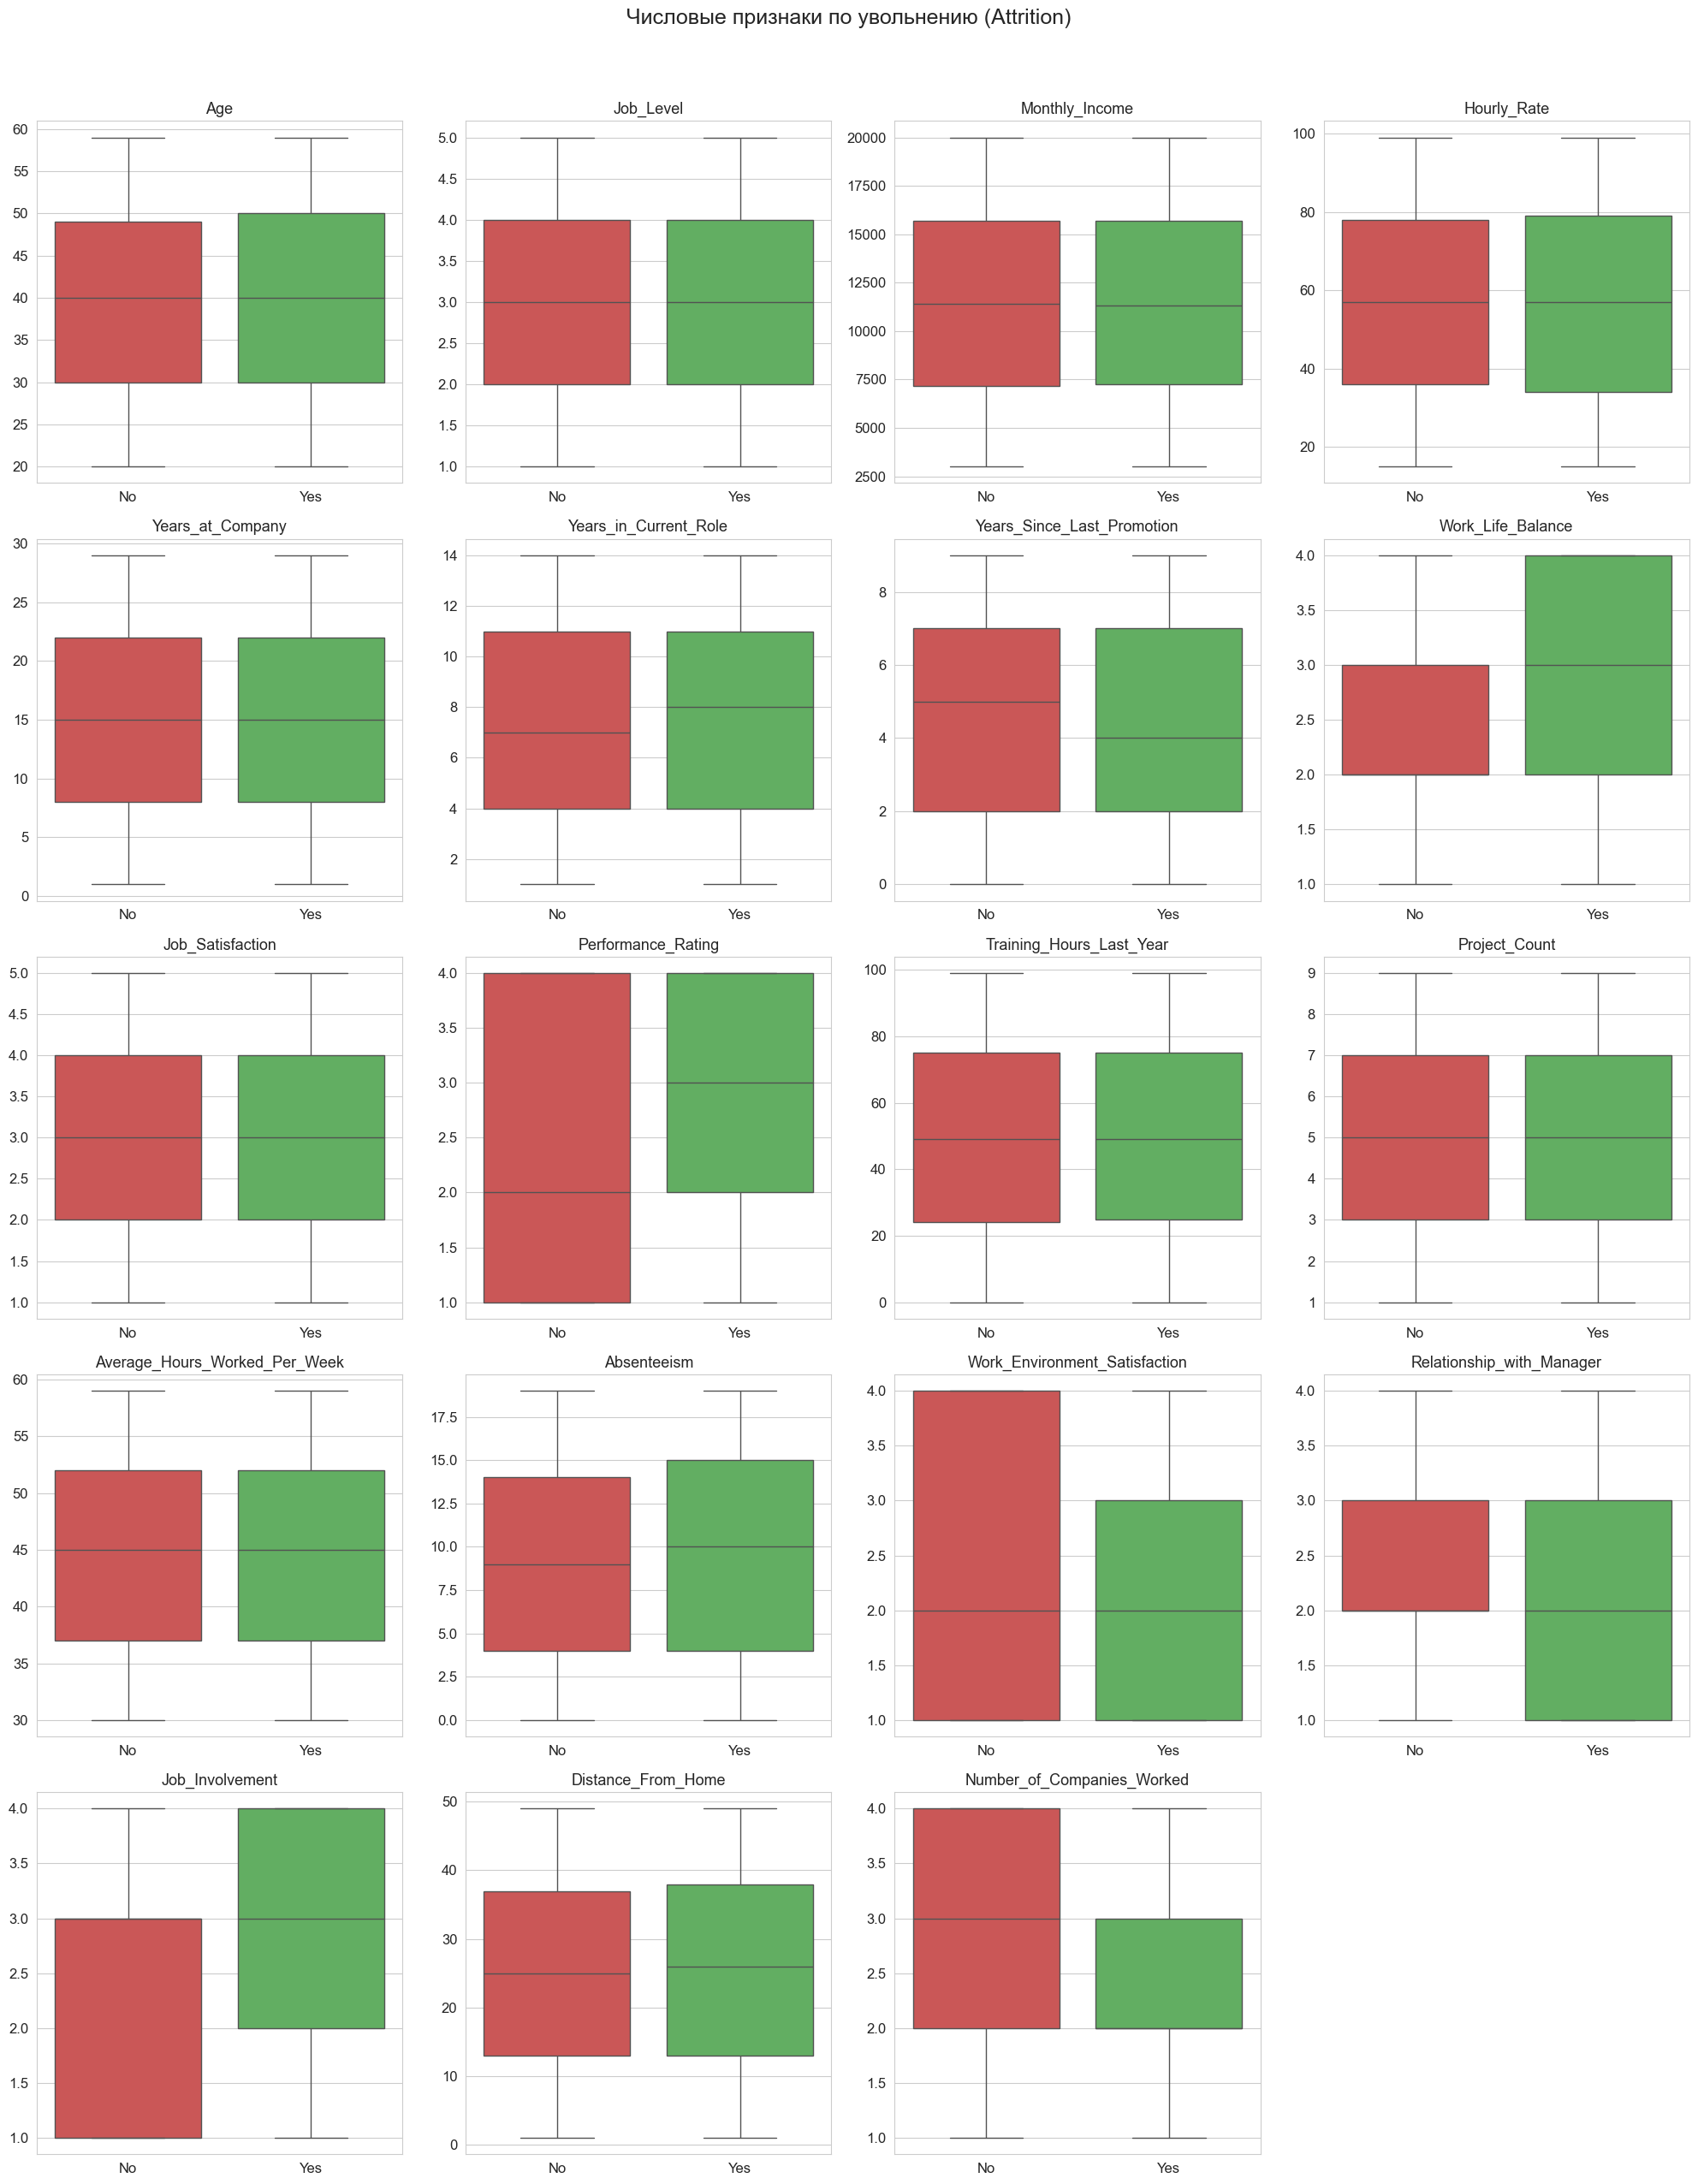

In [19]:
# Количество числовых признаков
n_cols = len(numeric_cols)
# Определяем сетку: 4 колонки, строки по необходимости
n_rows = (n_cols + 3) // 4  # если 8 признаков -> 2 строки, 9 -> 3 строки

fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 5))
axes = axes.flatten()  # превращаем в одномерный массив для удобства

colors = {'No': '#dd4444', 'Yes': '#55bb55'}

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Attrition', y=col, data=df, palette=colors, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Убираем лишние пустые графики (если нечетное число)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Числовые признаки по увольнению (Attrition)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## Корреляционная матрица числовых признаков

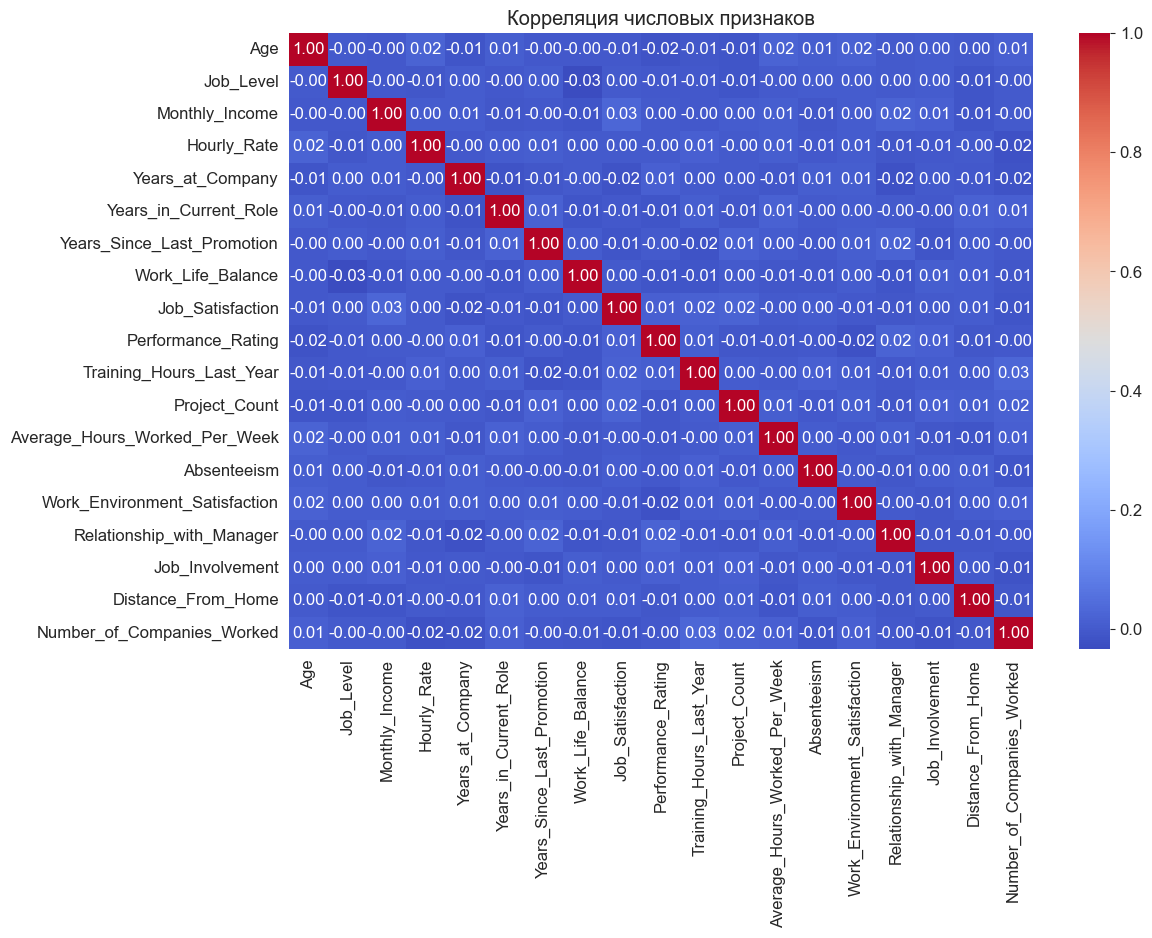

In [20]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

## Анализ категориальных признаков

In [21]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Категориальные признаки:', cat_cols)

Категориальные признаки: ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', 'Attrition']


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_28784\3530322768.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [22]:
# Частотность категорий
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- Gender ---
Gender
Female    5042
Male      4958
Name: count, dtype: int64

--- Marital_Status ---
Marital_Status
Married     3375
Divorced    3330
Single      3295
Name: count, dtype: int64

--- Department ---
Department
Marketing    2133
Sales        2008
Finance      1990
HR           1953
IT           1916
Name: count, dtype: int64

--- Job_Role ---
Job_Role
Analyst      2572
Assistant    2538
Executive    2476
Manager      2414
Name: count, dtype: int64

--- Overtime ---
Overtime
No     5103
Yes    4897
Name: count, dtype: int64

--- Attrition ---
Attrition
No     8003
Yes    1997
Name: count, dtype: int64


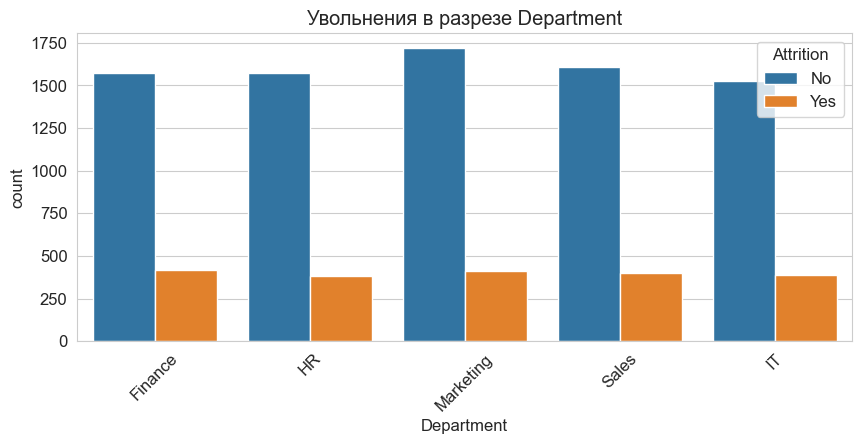

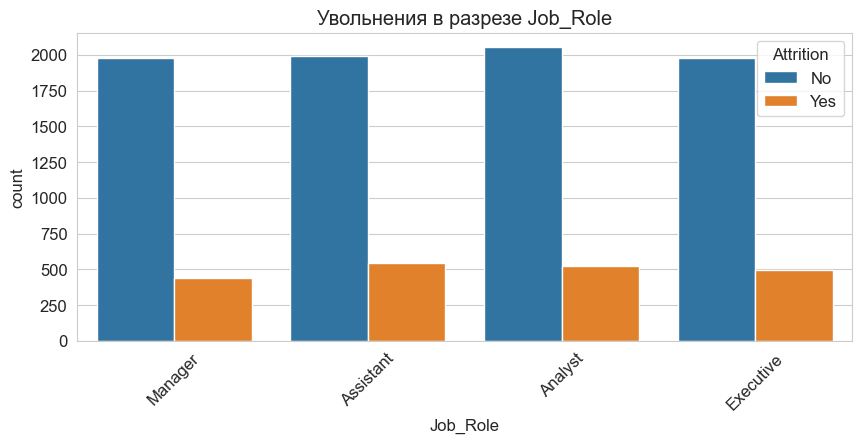

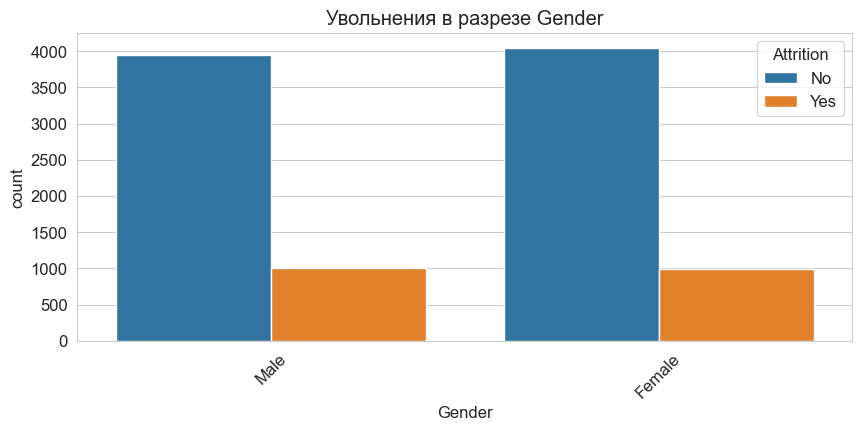

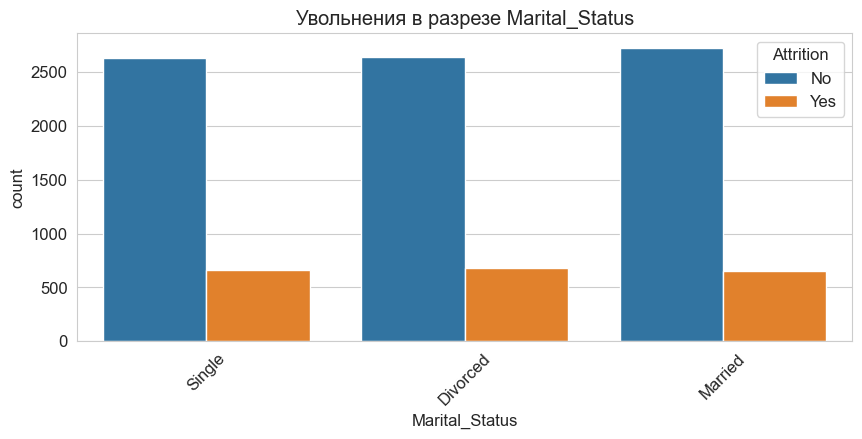

In [23]:
# Визуализация отношения категорий к увольнению (для некоторых ключевых)
key_cat_cols = ['Department', 'Job_Role', 'Gender', 'Marital_Status', 'Over_Time']
for col in key_cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        sns.countplot(x=col, hue='Attrition', data=df)
        plt.title(f'Увольнения в разрезе {col}')
        plt.xticks(rotation=45)
        plt.show()

## Выводы по EDA
1. Целевая переменная Attrition несбалансирована: уволившихся значительно меньше.
2. Пропуски и дубликаты отсутствуют.
3. Числовые признаки имеют различные масштабы – может потребоваться нормализация.
4. Некоторые числовые признаки (например, MonthlyIncome, Age) различаются в зависимости от увольнения.
5. Категориальные признаки (Department, Job_Role, Over_Time) показывают разную долю уволившихся.
6. Для моделирования потребуется кодирование категориальных признаков (One-Hot Encoding).